In [50]:
import sqlite3
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("parsakh/global-e-commerce-and-supply-chain-database")

In [52]:

conn = sqlite3.connect("ecommerce_supply_chain.db")
cursor = conn.cursor()

In [53]:
data_dir = "/home/codespace/.cache/kagglehub/datasets/parsakh/global-e-commerce-and-supply-chain-database/versions/1"

tables = {
    "inventory": "inventory.csv",
    "supplier_cost": "supplier_costs.csv",
    "products":"products.csv",
    "transactions":"transactions.csv"
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(data_dir, filename))
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows")

Loaded inventory: 500 rows
Loaded supplier_cost: 998 rows
Loaded products: 500 rows
Loaded transactions: 100000 rows


In [54]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM transactions t
"""
transactions_df = pd.read_sql_query(sql_query, conn)


In [55]:

sql_query = """SELECT *
FROM supplier_cost s
"""
supplier_df = pd.read_sql_query(sql_query, conn)



In [56]:

sql_query = """SELECT *
FROM products p
"""
product_df = pd.read_sql_query(sql_query, conn)



In [57]:

sql_query = """SELECT *
FROM inventory i
"""
inventory_df = pd.read_sql_query(sql_query, conn)



In [58]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   transaction_id     300000 non-null  str    
 1   customer_id        300000 non-null  str    
 2   product_id         300000 non-null  str    
 3   date               300000 non-null  str    
 4   quantity           300000 non-null  int64  
 5   unit_price_usd     300000 non-null  float64
 6   discount_pct       300000 non-null  float64
 7   revenue_usd        300000 non-null  float64
 8   cost_usd           300000 non-null  float64
 9   profit_usd         300000 non-null  float64
 10  shipping_cost_usd  300000 non-null  float64
 11  channel            300000 non-null  str    
 12  payment_method     300000 non-null  str    
 13  status             300000 non-null  str    
 14  country            300000 non-null  str    
 15  category           300000 non-null  str    
dtypes: float64(6)

In [59]:
supplier_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_id               1996 non-null   str    
 1   category                 1996 non-null   str    
 2   supplier_name            1996 non-null   str    
 3   supplier_rank            1996 non-null   int64  
 4   unit_cost_usd            1996 non-null   float64
 5   ordering_cost_usd        1996 non-null   float64
 6   annual_holding_cost_usd  1996 non-null   float64
 7   holding_cost_pct         1996 non-null   float64
 8   lead_time_days           1996 non-null   int64  
 9   min_order_qty            1996 non-null   int64  
 10  reliability_score        1996 non-null   float64
 11  is_primary               1996 non-null   int64  
dtypes: float64(5), int64(4), str(3)
memory usage: 187.3 KB


In [60]:
inventory_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   product_id          1000 non-null   str  
 1   category            1000 non-null   str  
 2   stock_units         1000 non-null   int64
 3   reorder_point       1000 non-null   int64
 4   warehouse_location  1000 non-null   str  
 5   last_restock_date   1000 non-null   str  
 6   supplier_lead_days  1000 non-null   int64
dtypes: int64(3), str(4)
memory usage: 54.8 KB


In [61]:
product_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1500 non-null   str    
 1   name            1500 non-null   str    
 2   category        1500 non-null   str    
 3   brand           1500 non-null   str    
 4   unit_price_usd  1500 non-null   float64
 5   unit_cost_usd   1500 non-null   float64
 6   weight_kg       1500 non-null   float64
 7   is_active       1500 non-null   int64  
 8   launch_date     1500 non-null   str    
dtypes: float64(3), int64(1), str(5)
memory usage: 105.6 KB


In [69]:
# Convert to datetime first if you haven't already
transactions_df["date"] = pd.to_datetime(transactions_df["date"])

# Print start and end dates
start_date = transactions_df["date"].min()
end_date = transactions_df["date"].max()

print(f"Data ranges from {start_date} to {end_date}")

Data ranges from 2022-01-01 00:00:00 to 2024-12-31 00:00:00


In [ ]:
import pandas as pd

sql_restock_analysis = """
WITH recent_sales AS (
    -- 1. Calculate units sold ONLY on or after the last restock date
    SELECT 
        p.product_id,
        p.brand,
        p.name AS product_name,
        i.stock_units AS current_stock,
        i.last_restock_date,
        -- Days elapsed between restock date and today
        CAST(julianday('now') - julianday(i.last_restock_date) AS INTEGER) AS days_since_restock,
        COALESCE(SUM(t.quantity), 0) AS units_sold_since_restock
    FROM products p
    JOIN inventory i ON p.product_id = i.product_id
    LEFT JOIN transactions t 
        ON p.product_id = t.product_id 
       AND DATE(t.date) >= DATE(i.last_restock_date)
    GROUP BY p.product_id, p.brand, p.name, i.stock_units, i.last_restock_date
),
velocity_metrics AS (
    -- 2. Calculate daily sales rate and remaining days of supply
    SELECT 
        brand,
        product_id,
        product_name,
        current_stock,
        last_restock_date,
        days_since_restock,
        units_sold_since_restock,
        -- Daily sales velocity since restock
        ROUND(
            CAST(units_sold_since_restock AS FLOAT) / MAX(days_since_restock, 1), 
            2
        ) AS daily_sales_rate
    FROM recent_sales
)
SELECT 
    brand,
    product_id,
    product_name,
    current_stock,
    last_restock_date,
    days_since_restock,
    units_sold_since_restock,
    daily_sales_rate,
    -- 3. Calculate Days of Supply Remaining
    CASE 
        WHEN daily_sales_rate = 0 AND current_stock > 0 THEN 9999 -- Zero movement since restock
        ELSE ROUND(CAST(current_stock AS FLOAT) / NULLIF(daily_sales_rate, 0), 1)
    END AS days_of_supply_remaining,
    -- 4. Dynamic Overstock Status
    CASE 
        WHEN daily_sales_rate = 0 AND days_since_restock > 30 THEN 'DEAD STOCK (No sales since restock)'
        WHEN (CAST(current_stock AS FLOAT) / NULLIF(daily_sales_rate, 0)) > 180 THEN 'OVERSTOCKED (>6 Months Supply)'
        WHEN (CAST(current_stock AS FLOAT) / NULLIF(daily_sales_rate, 0)) < 14 THEN 'LOW STOCK (<2 Weeks Supply)'
        ELSE 'HEALTHY'
    END AS inventory_status
FROM velocity_metrics
WHERE current_stock > 0
ORDER BY days_of_supply_remaining DESC;
"""

df_restock = pd.read_sql_query(sql_restock_analysis, conn)

In [101]:
df_restock.head()

,brand,product_id,product_name,current_stock,last_restock_date,days_since_restock,units_sold_since_restock,daily_sales_rate,days_of_supply_remaining,inventory_status
0,ClearView,PROD0005,HomePro Clothing Item 5,21,2024-12-28,576,0,0.0,9999.0,DEAD STOCK (No sales since restock)
1,GlowUp,PROD0019,StyleCo Beauty Item 19,17,2024-12-27,577,0,0.0,9999.0,DEAD STOCK (No sales since restock)
2,BoldEdge,PROD0042,NexGen Electronics Item 42,5,2024-12-26,578,0,0.0,9999.0,DEAD STOCK (No sales since restock)
3,BoldEdge,PROD0053,CoreBrand Home Item 53,17,2024-12-14,590,0,0.0,9999.0,DEAD STOCK (No sales since restock)
4,BoldEdge,PROD0077,ReadMore Home Item 77,5,2024-12-28,576,0,0.0,9999.0,DEAD STOCK (No sales since restock)


/tmp/ipykernel_4237/2204239912.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


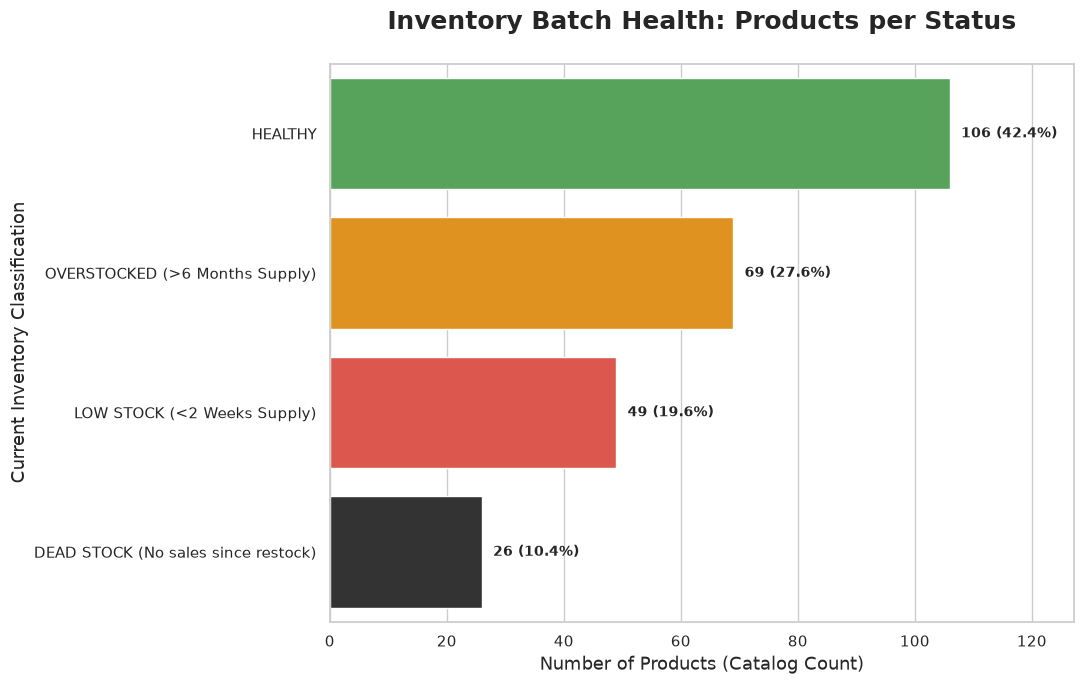

In [ ]:

# 1. Setup Sample Data (assuming df_restock from previous step exists)
# If running this alone, create sample data based on query output:
import numpy as np
np.random.seed(101)
status_options = ['HEALTHY', 'OVERSTOCKED (>6 Months Supply)', 'LOW STOCK (<2 Weeks Supply)', 'DEAD STOCK (No sales since restock)']
df_restock = pd.DataFrame({'inventory_status': np.random.choice(status_options, 250, p=[0.45, 0.25, 0.20, 0.10])})

# 2. Configure Visualization Settings
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

# Define colors semantically (Green, Orange, Red, Dark Gray)
custom_palette = ['#4caf50', '#ff9800', '#f44336', '#333333']

# 3. Create the Visualization (Horizontal Countplot)
ax = sns.countplot(
    data=df_restock,
    y='inventory_status', # Horizontal orientation
    order=status_options, # Consistent sorting order
    palette=custom_palette # Apply semantic colors
)

# 4. Add Data Labels (Counts and Percentages)
total = len(df_restock)
for p in ax.patches:
    width = p.get_width() # Get the count (bar length)
    percentage = f'{100 * width / total:.1f}%' # Calculate % of total catalog
    if width > 0:
        ax.annotate(f'{int(width):,} ({percentage})',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=10, fontweight='bold')

# 5. Formatting & Labels
plt.title('Inventory Batch Health: Products per Status', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Number of Products (Catalog Count)', fontsize=13)
plt.ylabel('Current Inventory Classification', fontsize=13)

# Adjust margins to fit labels comfortably
plt.xlim(0, max(df_restock['inventory_status'].value_counts()) * 1.20)
plt.tight_layout()

plt.show()

In [114]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

In [122]:
sql_query = """
WITH post_restock_sales AS (
    -- Group transactions by product_id post-restock date first
    SELECT 
        p.product_id,
        p.brand,
        i.stock_units AS units_on_hand,
        COALESCE(SUM(t.quantity), 0) AS units_sold_since_restock
    FROM products p
    JOIN inventory i 
        ON p.product_id = i.product_id
    LEFT JOIN transactions t 
        ON p.product_id = t.product_id 
       AND DATE(t.date) >= DATE(i.last_restock_date)
    GROUP BY 
        p.product_id, 
        p.brand, 
        i.stock_units
)
SELECT 
    brand,
    SUM(units_sold_since_restock) AS total_units_sold,
    SUM(units_on_hand) AS total_units_on_hand,
    ROUND(
        (SUM(units_sold_since_restock) * 100.0) / 
        NULLIF(SUM(units_sold_since_restock) + SUM(units_on_hand), 0), 
        2
    ) AS brand_sell_through_rate_pct
FROM post_restock_sales
GROUP BY brand
ORDER BY brand_sell_through_rate_pct ASC;
"""

df_product = pd.read_sql_query(sql_query, conn)

In [123]:
df_product.head()

,brand,total_units_sold,total_units_on_hand,brand_sell_through_rate_pct
0,PrimeLine,15930,759,95.45
1,StyleCo,25362,988,96.25
2,NexGen,14580,536,96.45
3,ActiveGear,13392,479,96.55
4,NovaTech,22068,789,96.55


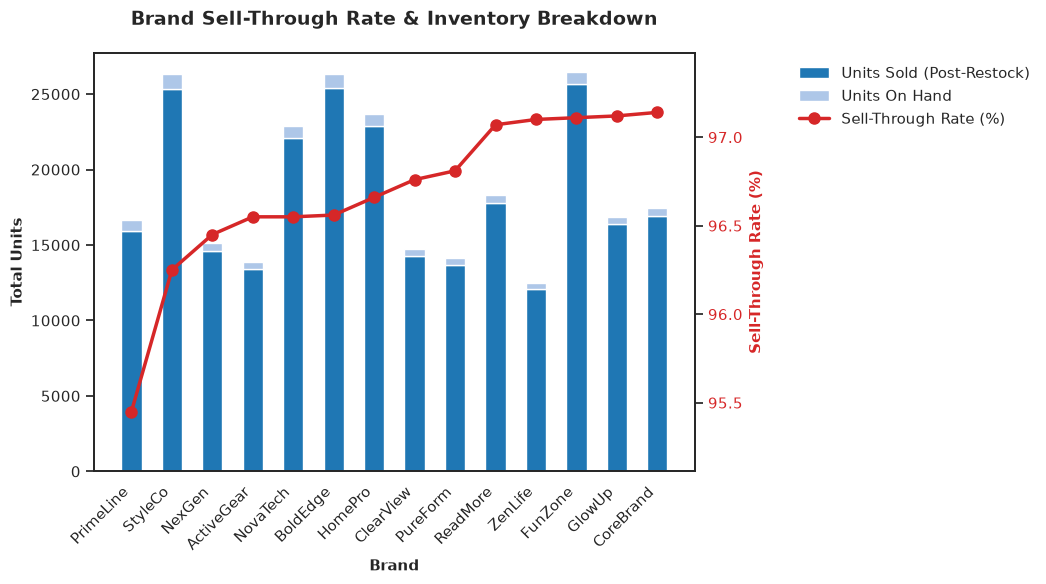

In [141]:

# Set visual style
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(11, 6))

# Plot Stacked Bars for Volumes
brands = df_product["brand"]
sold = df_product["total_units_sold"]
on_hand = df_product["total_units_on_hand"]

bar1 = ax1.bar(
    brands, sold, label="Units Sold (Post-Restock)", color="#1f77b4", width=0.5
)
bar2 = ax1.bar(
    brands,
    on_hand,
    bottom=sold,
    label="Units On Hand",
    color="#aec7e8",
    width=0.5,
)

ax1.set_ylabel("Total Units", fontsize=11, fontweight="bold")
ax1.set_xlabel("Brand", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y")

# Rotate X-axis brand labels by 45 degrees
ax1.set_xticks(range(len(brands)))
ax1.set_xticklabels(brands, rotation=45, ha="right")

# Create secondary Y-axis for Sell-Through Percentage
ax2 = ax1.twinx()
line = ax2.plot(
    brands,
    df_product["brand_sell_through_rate_pct"],
    color="#d62728",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Sell-Through Rate (%)",
)

ax2.set_ylabel(
    "Sell-Through Rate (%)", fontsize=11, fontweight="bold", color="#d62728"
)
ax2.tick_params(axis="y", labelcolor="#d62728")

# Dynamic Y-axis scaling for sell-through rate with padding for rotated text
min_val = df_product["brand_sell_through_rate_pct"].min()
max_val = df_product["brand_sell_through_rate_pct"].max()
padding = (max_val - min_val) * 0.2 if max_val != min_val else 10
ax2.set_ylim(max(0, min_val - padding), max_val + padding)
# Title
plt.title(
    "Brand Sell-Through Rate & Inventory Breakdown",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Move Legend Outside the Plot to the Right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(1.15, 1.0),  # Places legend outside on the right
    frameon=False,
)

plt.tight_layout()
plt.show()

In [144]:
sql_query = """
WITH post_restock_metrics AS (
    SELECT 
        p.product_id,
        p.brand,
        p.name AS product_name,
        i.stock_units AS units_on_hand,
        i.last_restock_date,
        -- Calculate active days since last restock (minimum 1 day to avoid division by zero)
        MAX(1, CAST(julianday('now') - julianday(i.last_restock_date) AS INTEGER)) AS days_since_restock,
        -- Units sold ONLY since the last restock
        COALESCE(SUM(t.quantity), 0) AS units_sold_since_restock
    FROM products p
    JOIN inventory i 
        ON p.product_id = i.product_id
    LEFT JOIN transactions t 
        ON p.product_id = t.product_id 
       AND DATE(t.date) >= DATE(i.last_restock_date)
    WHERE i.stock_units > 0 -- Focus only on items currently holding inventory
    GROUP BY 
        p.product_id, 
        p.brand, 
        p.name, 
        i.stock_units, 
        i.last_restock_date
),
velocity_analysis AS (
    SELECT 
        brand,
        product_id,
        product_name,
        units_on_hand,
        last_restock_date,
        days_since_restock,
        units_sold_since_restock,
        -- Daily Sales Rate (Velocity)
        ROUND(CAST(units_sold_since_restock AS FLOAT) / days_since_restock, 3) AS daily_sales_rate
    FROM post_restock_metrics
)
SELECT 
    brand,
    product_id,
    product_name,
    last_restock_date,
    units_on_hand,
    units_sold_since_restock,
    daily_sales_rate,
    -- Estimate remaining days of inventory supply
    CASE 
        WHEN daily_sales_rate = 0 THEN 9999 -- Extremely slow or dead stock
        ELSE ROUND(CAST(units_on_hand AS FLOAT) / daily_sales_rate, 1)
    END AS days_of_supply_remaining,
    -- Classification Flag
    CASE 
        WHEN daily_sales_rate = 0 AND days_since_restock >= 30 THEN 'CRITICAL: Dead Stock (No sales since restock)'
        WHEN (CAST(units_on_hand AS FLOAT) / NULLIF(daily_sales_rate, 0)) >= 365 THEN 'HIGH RISK: > 1 Year Supply'
        WHEN (CAST(units_on_hand AS FLOAT) / NULLIF(daily_sales_rate, 0)) >= 180 THEN 'MODERATE RISK: 6-12 Months Supply'
        ELSE 'SLIGHT OVERSTOCK'
    END AS overstock_severity
FROM velocity_analysis
-- Filter for products with over 180 days (6 months) of inventory or zero movement after 30 days
WHERE (daily_sales_rate = 0 AND days_since_restock >= 30)
   OR (units_on_hand / NULLIF(daily_sales_rate, 0)) >= 180
ORDER BY days_of_supply_remaining DESC, units_on_hand DESC;
"""

overstock_df = pd.read_sql_query(sql_query, conn)


In [145]:

overstock_df.head()

,brand,product_id,product_name,last_restock_date,units_on_hand,units_sold_since_restock,daily_sales_rate,days_of_supply_remaining,overstock_severity
0,PrimeLine,PROD0486,ReadMore Toys Item 486,2024-12-30,45,0,0.0,9999.0,CRITICAL: Dead Stock (No sales since restock)
1,ReadMore,PROD0231,StyleCo Electronics Item 231,2024-12-29,25,0,0.0,9999.0,CRITICAL: Dead Stock (No sales since restock)
2,ActiveGear,PROD0146,HomePro Home Item 146,2024-12-24,23,0,0.0,9999.0,CRITICAL: Dead Stock (No sales since restock)
3,ClearView,PROD0005,HomePro Clothing Item 5,2024-12-28,21,0,0.0,9999.0,CRITICAL: Dead Stock (No sales since restock)
4,PrimeLine,PROD0246,GlowUp Clothing Item 246,2024-12-30,20,0,0.0,9999.0,CRITICAL: Dead Stock (No sales since restock)


/tmp/ipykernel_4237/1451391655.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4237/1451391655.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


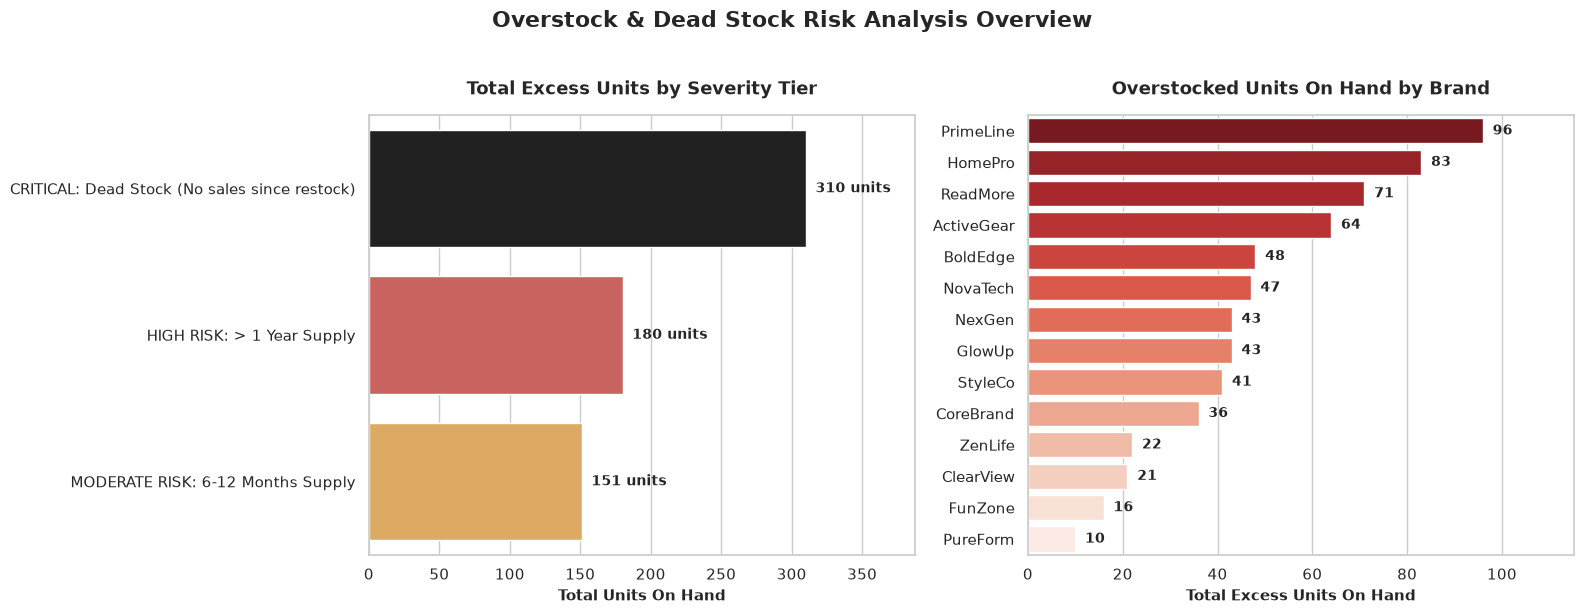

In [ ]:

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Custom palette tied directly to risk severity
severity_colors = {
    'CRITICAL: Dead Stock (No sales since restock)': '#212121',  # Charcoal Black
    'HIGH RISK: > 1 Year Supply': '#d9534f',                    # Dark Red
    'MODERATE RISK: 6-12 Months Supply': '#f0ad4e',            # Amber/Orange
    'SLIGHT OVERSTOCK': '#5bc0de'                               # Light Blue
}

# 1. Plot: Total Units On Hand by Severity Tier
sev_order = [
    'CRITICAL: Dead Stock (No sales since restock)',
    'HIGH RISK: > 1 Year Supply',
    'MODERATE RISK: 6-12 Months Supply',
    'SLIGHT OVERSTOCK'
]

sev_summary = (
    overstock_df.groupby('overstock_severity')['units_on_hand']
    .sum()
    .reindex(sev_order)
    .dropna()
    .reset_index()
)

sns.barplot(
    data=sev_summary,
    y='overstock_severity',
    x='units_on_hand',
    palette=severity_colors,
    ax=ax1
)
ax1.set_title('Total Excess Units by Severity Tier', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Total Units On Hand', fontsize=11, fontweight='bold')
ax1.set_ylabel('')

# Annotate unit counts on bars
for p in ax1.patches:
    width = p.get_width()
    if width > 0:
        ax1.annotate(f'{int(width):,} units',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(7, 0), textcoords='offset points',
                    fontsize=10, fontweight='bold')

ax1.set_xlim(0, sev_summary['units_on_hand'].max() * 1.25)

# 2. Plot: Overstocked Units by Brand
brand_summary = (
    overstock_df.groupby('brand')['units_on_hand']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=brand_summary,
    x='units_on_hand',
    y='brand',
    palette='Reds_r',
    ax=ax2
)
ax2.set_title('Overstocked Units On Hand by Brand', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Total Excess Units On Hand', fontsize=11, fontweight='bold')
ax2.set_ylabel('')

for p in ax2.patches:
    width = p.get_width()
    if width > 0:
        ax2.annotate(f'{int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(7, 0), textcoords='offset points',
                    fontsize=10, fontweight='bold')

ax2.set_xlim(0, brand_summary['units_on_hand'].max() * 1.20)

plt.suptitle('Overstock & Dead Stock Risk Analysis Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [148]:
sql_query = """
WITH post_restock_metrics AS (
    SELECT 
        p.product_id,
        p.brand,
        p.name AS product_name,
        i.stock_units AS units_on_hand,
        i.last_restock_date,
        -- Days since last restock (at least 1 to prevent division by zero)
        MAX(1, CAST(julianday('now') - julianday(i.last_restock_date) AS INTEGER)) AS days_since_restock,
        -- Units sold ONLY since last restock
        COALESCE(SUM(t.quantity), 0) AS units_sold_since_restock
    FROM products p
    JOIN inventory i 
        ON p.product_id = i.product_id
    LEFT JOIN transactions t 
        ON p.product_id = t.product_id 
       AND DATE(t.date) >= DATE(i.last_restock_date)
    WHERE i.stock_units > 0 -- Focus on items currently in stock
    GROUP BY 
        p.product_id, 
        p.brand, 
        p.name, 
        i.stock_units, 
        i.last_restock_date
),
velocity_analysis AS (
    SELECT 
        brand,
        product_id,
        product_name,
        units_on_hand,
        last_restock_date,
        days_since_restock,
        units_sold_since_restock,
        -- Calculate daily sales rate
        ROUND(CAST(units_sold_since_restock AS FLOAT) / days_since_restock, 2) AS daily_sales_rate
    FROM post_restock_metrics
    WHERE units_sold_since_restock > 0 -- Must have active sales momentum
)
SELECT 
    brand,
    product_id,
    product_name,
    last_restock_date,
    units_on_hand,
    units_sold_since_restock,
    daily_sales_rate,
    -- Estimated Days of Supply Remaining
    ROUND(CAST(units_on_hand AS FLOAT) / daily_sales_rate, 1) AS days_of_supply_remaining,
    -- Priority Classification
    CASE 
        WHEN (CAST(units_on_hand AS FLOAT) / daily_sales_rate) <= 3 THEN 'URGENT: Stockout in ≤ 3 Days'
        WHEN (CAST(units_on_hand AS FLOAT) / daily_sales_rate) <= 7 THEN 'HIGH RISK: Stockout in 4-7 Days'
        WHEN (CAST(units_on_hand AS FLOAT) / daily_sales_rate) <= 14 THEN 'MODERATE RISK: Stockout in 8-14 Days'
        ELSE 'LOW RISK'
    END AS stockout_urgency
FROM velocity_analysis
-- Filter for high-velocity items with 14 days or less of supply left
WHERE (CAST(units_on_hand AS FLOAT) / daily_sales_rate) <= 14
ORDER BY days_of_supply_remaining ASC, daily_sales_rate DESC;
"""

stockout_df = pd.read_sql_query(sql_query, conn)

In [149]:
stockout_df.head()

,brand,product_id,product_name,last_restock_date,units_on_hand,units_sold_since_restock,daily_sales_rate,days_of_supply_remaining,stockout_urgency
0,ReadMore,PROD0211,PureForm Toys Item 211,2024-10-06,3,900,1.37,2.2,URGENT: Stockout in ≤ 3 Days
1,PureForm,PROD0254,NovaTech Clothing Item 254,2024-10-06,2,540,0.82,2.4,URGENT: Stockout in ≤ 3 Days
2,ReadMore,PROD0245,PrimeLine Clothing Item 245,2024-11-12,2,486,0.78,2.6,URGENT: Stockout in ≤ 3 Days
3,ActiveGear,PROD0040,PrimeLine Electronics Item 40,2024-10-18,4,936,1.45,2.8,URGENT: Stockout in ≤ 3 Days
4,PrimeLine,PROD0418,NexGen Books Item 418,2024-10-23,6,1314,2.05,2.9,URGENT: Stockout in ≤ 3 Days


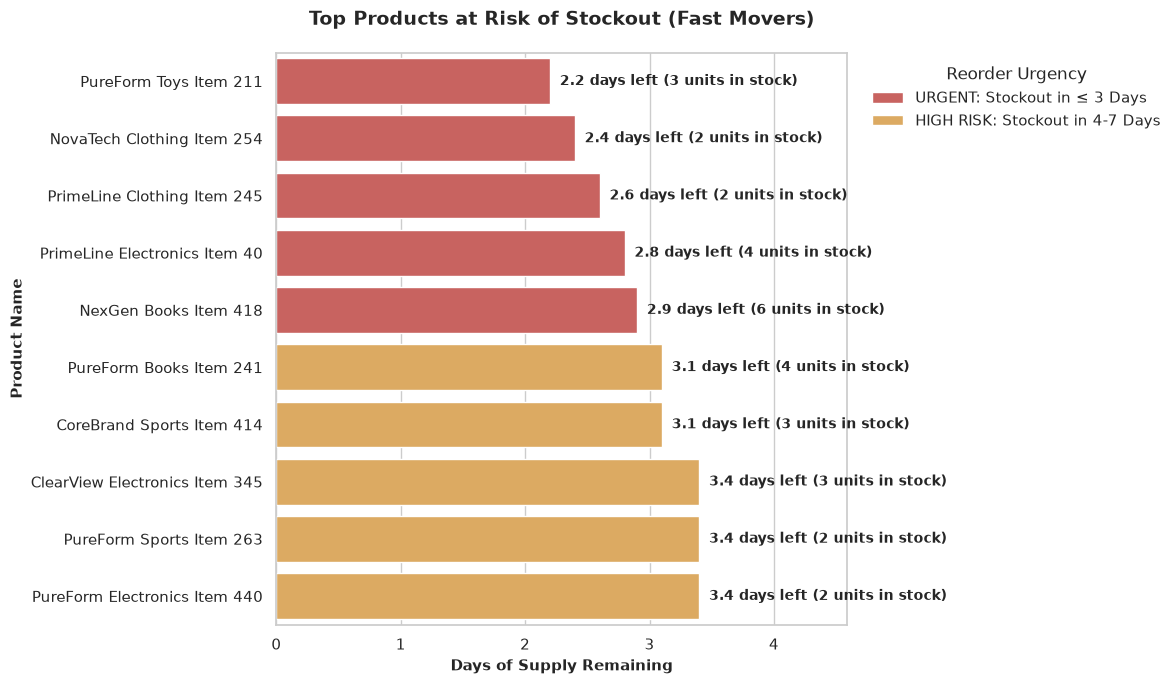

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Sort products by urgency (fewest days left at top)
plot_df = stockout_df.sort_values(
    "days_of_supply_remaining", ascending=True
).head(10)

# Custom color scheme for stockout urgency
urgency_colors = {
    "URGENT: Stockout in ≤ 3 Days": "#d9534f",  # Crimson Red
    "HIGH RISK: Stockout in 4-7 Days": "#f0ad4e",  # Warning Amber
    "MODERATE RISK: Stockout in 8-14 Days": "#5bc0de",  # Cyan Blue
}

# Horizontal bar plot
sns.barplot(
    data=plot_df,
    y="product_name",
    x="days_of_supply_remaining",
    hue="stockout_urgency",
    palette=urgency_colors,
    dodge=False,
    ax=ax,
)

# Annotate bars with exact days left and units on hand
for p, (_, row) in zip(ax.patches, plot_df.iterrows()):
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.1f} days left ({int(row['units_on_hand'])} units in stock)",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            xytext=(7, 0),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# Titles and Axis formatting
ax.set_title(
    "Top Products at Risk of Stockout (Fast Movers)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Days of Supply Remaining", fontsize=11, fontweight="bold")
ax.set_ylabel("Product Name", fontsize=11, fontweight="bold")
ax.set_xlim(0, plot_df["days_of_supply_remaining"].max() * 1.35)

# Place legend outside to the right
plt.legend(
    title="Reorder Urgency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

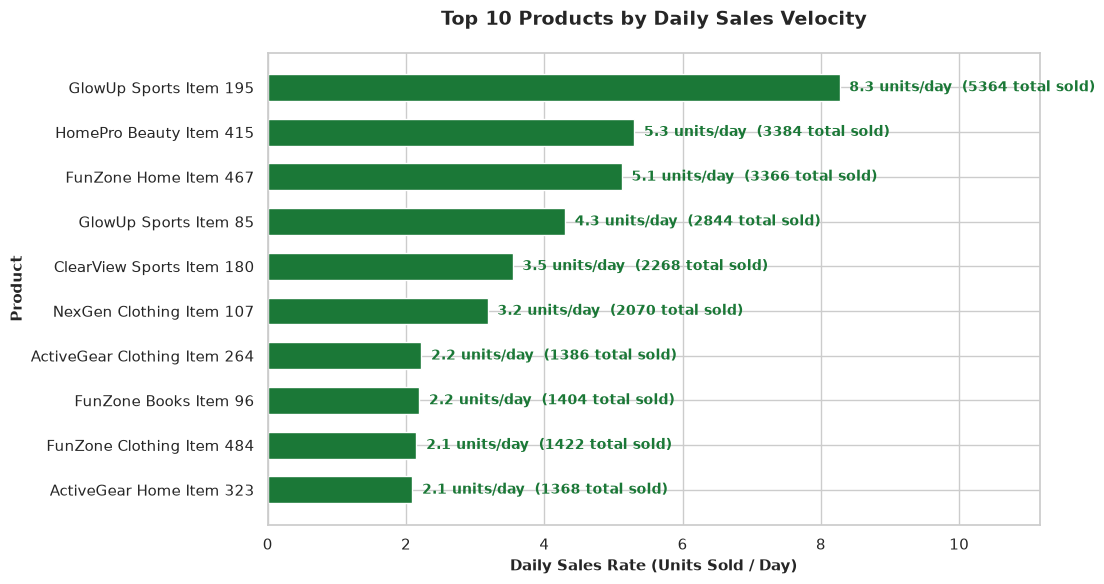

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

# Grab top 10 products sorted so the fastest mover is at the top
top_products_df = (
    stockout_df.sort_values("daily_sales_rate", ascending=False)
    .head(10)
    .sort_values("daily_sales_rate", ascending=True)
)

# Horizontal bar chart
bars = ax.barh(
    top_products_df["product_name"],
    top_products_df["daily_sales_rate"],
    color="#1b7837",  # Deep emerald green for top performers
    height=0.6,
)

# Add data annotations next to each bar
for bar, (_, row) in zip(bars, top_products_df.iterrows()):
    width = bar.get_width()
    ax.annotate(
        f"{width:.1f} units/day  ({int(row['units_sold_since_restock'])} total sold)",
        (width, bar.get_y() + bar.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(7, 0),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#1b7837",
    )

# Formatting title and axes
ax.set_title(
    "Top 10 Products by Daily Sales Velocity",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel(
    "Daily Sales Rate (Units Sold / Day)", fontsize=11, fontweight="bold"
)
ax.set_ylabel("Product", fontsize=11, fontweight="bold")

# Give extra clearance on the right for annotations
ax.set_xlim(0, top_products_df["daily_sales_rate"].max() * 1.35)
plt.tight_layout()
plt.show()